# GB  on  4  features 



In [1]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18


## 1) Imports & config

In [2]:
# ---- choose model: "rf" or "hgb" ----
MODEL = "hgb"  # set to "rf" to go back

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("5;23")                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=123
)
# hgb.fit(Xtr, ytr)  # <-- comment this until Xtr, ytr exist




The in R studion done 4 feature were computed an used for the training.

In [3]:
# ---- shape feature builder: returns X (DataFrame) ----
import re
import numpy as np
import pandas as pd

FAMILIES    = [
    "HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
    
]   # edit if needed
KEEP_WINDOW = (5, 23)                   # inclusive positions
EXCLUDE_IF_CONTAINS = ("rep",)          # optional substring filter

def build_X_feature(df: pd.DataFrame,
            families=FAMILIES,
            keep_window=KEEP_WINDOW,
            exclude_contains=EXCLUDE_IF_CONTAINS) -> pd.DataFrame:
    """Select MGW/ProT/Roll columns with trailing _pos index in [6..24] and return numeric DataFrame."""
    start_idx, end_idx = keep_window
    cols = []
    for c in df.columns:
        base = c.split("_")[0] if "_" in c else None
        if base not in families:
            continue
        m = re.search(r"_(\d+)$", c)
        if not m:
            continue
        pos = int(m.group(1))
        if not (start_idx <= pos <= end_idx):
            continue
        if exclude_contains and any(s in c for s in exclude_contains):
            continue
        cols.append(c)
    # numeric df (no imputation/variance here)
    return df[cols].apply(pd.to_numeric, errors="coerce")




## 4) Train, calibrate, evaluate

In [4]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Load & filter
df = pd.read_csv(INFILE)

df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Features (ensure build_X does NOT impute; we impute AFTER the split)
X = build_X_feature(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED,
    stratify=bins if bins is not None else None
)
# 6) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    """Return higher weights for low and high tails of y."""
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)


# 5) Train-only variance filter + imputer (prevents leakage)
var_mask = Xtr.var(ddof=0) > 1e-12
Xtr = Xtr.loc[:, var_mask]
Xte = Xte.loc[:, var_mask.index[var_mask]]

imp = SimpleImputer(strategy="mean")
Xtr = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
Xte = pd.DataFrame(imp.transform(Xte),   columns=Xte.columns, index=Xte.index)

# ---- Gradient Boosting instead of Random Forest ----
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

est = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=SEED,
)

# fit (with weights if your sklearn version supports it)
try:
    est.fit(Xtr, ytr, sample_weight=wtr)
except TypeError:
    # older sklearn: no sample_weight support; fall back to unweighted fit
    est.fit(Xtr, ytr)

print("Train R² (HGB):", r2_score(ytr, est.predict(Xtr)))

# keep downstream variable name the same so the rest of your notebook works
rf = est




Train R² (HGB): 0.8935670033146117


## 5) Plots & saving predictions

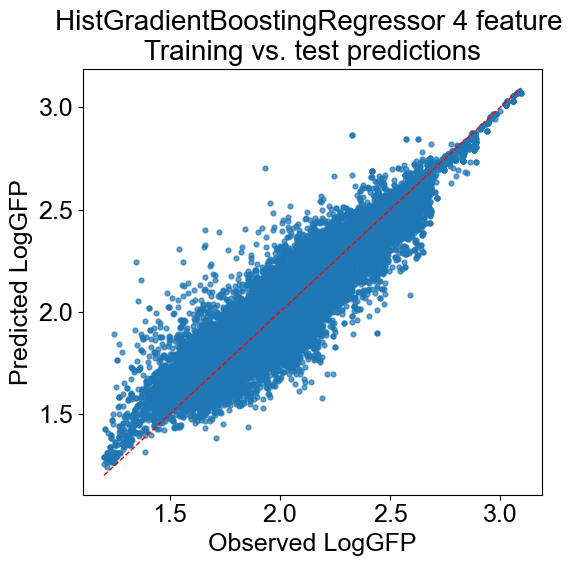

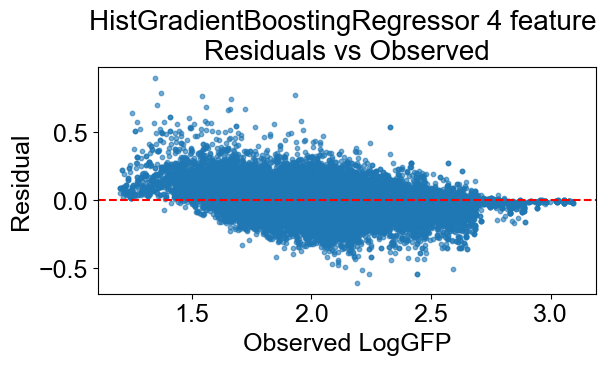

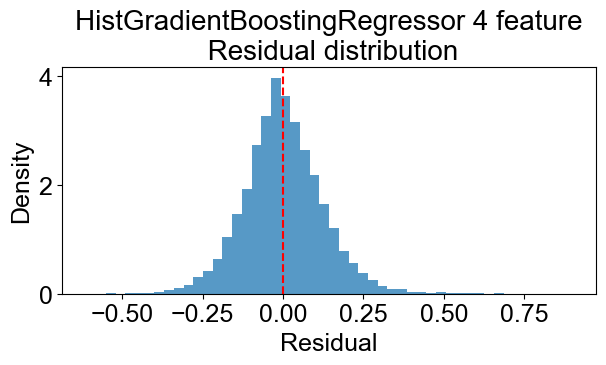

Saved: seq_rf_preds.csv
Mean residual: 0.0012302281050261712


In [5]:
# ---- Compute predictions cleanly ----
y_pred = rf.predict(Xte)          # <--- use your model here (rf / hgb / etc.)
y_pred = np.array(y_pred).ravel() # ensure 1D

# If you had a raw model output (e.g., before calibration) define it here
# Otherwise, just set it equal:
y_pred_raw = y_pred.copy()

# ---- Helper to save plots ----
def show_and_save(fig, name):
    fig.tight_layout()
    fig.savefig(f"{OUT}_{name}.png", dpi=300)
    plt.show()
    plt.close(fig)

# ---- 1. Predicted vs Observed ----
fig = plt.figure(figsize=(6,6))
plt.scatter(yte, y_pred, s=12, alpha=0.7)

lo = float(min(yte.min(), y_pred.min()))
hi = float(max(yte.max(), y_pred.max()))
plt.plot([lo,hi], [lo,hi], 'r--', lw=1)

plt.xlabel("Observed LogGFP")
plt.ylabel("Predicted LogGFP")
plt.title("HistGradientBoostingRegressor 4 feature \n"
    "Training vs. test predictions"
)




show_and_save(fig, "pred_vs_obs")

# ---- 2. Residuals ----
res = y_pred - yte

fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte, res, s=10, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP")
plt.ylabel("Residual")
plt.title("HistGradientBoostingRegressor 4 feature \n"
          "Residuals vs Observed")

show_and_save(fig, "residuals_vs_obs")

# ---- 3. Residual distribution ----
fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--')
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("HistGradientBoostingRegressor 4 feature\n"
          " Residual distribution")

show_and_save(fig, "residual_hist")

# ---- 4. Export CSV ----
pd.DataFrame({
    "y_true": yte,
    "y_pred_raw": y_pred_raw,
    "y_pred": y_pred
}).to_csv(f"{OUT}_preds.csv", index=False)

print("Saved:", f"{OUT}_preds.csv")

bias = res.mean()
print("Mean residual:", bias)


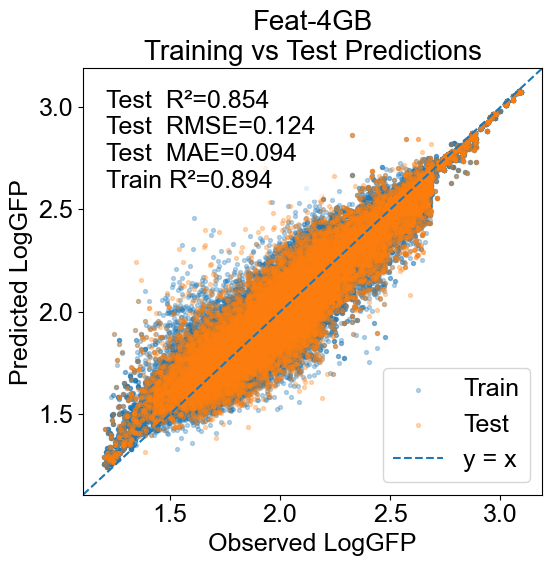

In [6]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF 13 Features— Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    


    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))
    mpl.rcParams['svg.fonttype'] = 'none' 
    plt.tight_layout()
    plt.savefig("HistGradientBoostingRegressor 4 feature Training vs Test Predictions.png", dpi=600, bbox_inches="tight")
    plt.savefig(
    "Feat-4GB vs Test Predictions.pdf",
    bbox_inches="tight"
)
    plt.show()


# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="Feat-4GB\n"
          "Training vs Test Predictions",
                      )



# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


Blue points (Train): predictions on your training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

see the distribution

77874 19469 4.0
Middle counts 1.90–2.00: train= 9649 test= 2435


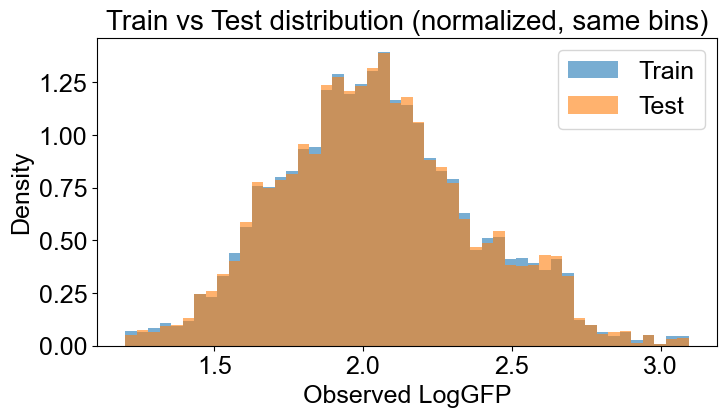

Train quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.951
0.5    2.031
0.6    2.105
0.7    2.197
0.8    2.314
0.9    2.506
1.0    3.094
dtype: float64

Test quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.950
0.5    2.031
0.6    2.106
0.7    2.197
0.8    2.313
0.9    2.505
1.0    3.094
dtype: float64


In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) Confirm sizes (should be ~80/20)
print(len(ytr), len(yte), round(len(ytr)/len(yte), 3))

# 2) Count samples in the “middle” band, e.g. 1.90–2.00
mid_mask_tr = (ytr >= 1.90) & (ytr <= 2.00)
mid_mask_te = (yte >= 1.90) & (yte <= 2.00)
print("Middle counts 1.90–2.00:",
      "train=", mid_mask_tr.sum(),
      "test=",  mid_mask_te.sum())

# 3) Compare shapes with SAME bins and density (so areas match)
bins = np.linspace(y.min(), y.max(), 50)
plt.figure(figsize=(8,4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP"); plt.ylabel("Density")
plt.title("Train vs Test distribution (normalized, same bins)")
plt.legend(); plt.show()

# 4) Quantile table to see coverage across the range
qs = np.linspace(0,1,11)
print("Train quantiles:\n", pd.Series(ytr).quantile(qs).round(3))
print("\nTest quantiles:\n",  pd.Series(yte).quantile(qs).round(3))


the saved model

In [8]:

import joblib, json, time

bundle = {
    "version": "shape_rf_v1",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "families": FAMILIES,
    "keep_window": KEEP_WINDOW,
    "exclude": EXCLUDE_IF_CONTAINS,
    "rf_params": getattr(rf, "get_params", lambda: {})(),
    "seed": SEED,
    "feature_columns": list(Xtr.columns),
    "imputer": imp,
    "calibrator": None,
    "model": rf,
  
}
bundle["y_true_te"] = yte          # true test labels
bundle["y_pred_te"] = y_pred      # the only predictions you care about




joblib.dump(bundle, "shape_booster4_model.joblib")
print("Saved: shape_booster4_model.joblib")

Saved: shape_booster4_model.joblib


In [9]:
# ===== Config =====
MODEL_PATH = "shape_booster4_model.joblib"        # <- your trained model file
NEW_FILE   = "All_Fasta_sequnes_constructed_features.csv"              # <- your input file (infile)
OUT_FILE   = "predictionsno_calibrated_feature.tsv"  # <- your output file (outfile)


Beeswarm

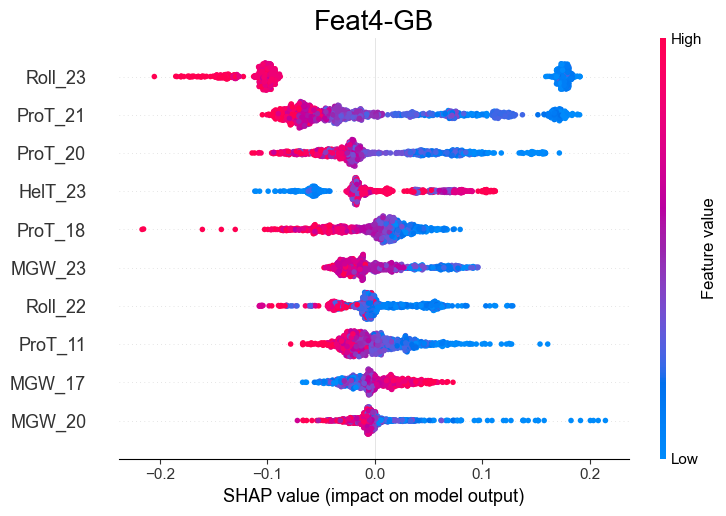

In [14]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# --- Align features to the model ---
if not isinstance(Xte, pd.DataFrame):
    Xte_df = pd.DataFrame(Xte, columns=rf.feature_names_in_)
else:
    Xte_df = Xte.copy()

Xte_df = Xte_df[rf.feature_names_in_]

# --- Subsample ---
n_sample = min(len(Xte_df), 1000)
Xte_df = Xte_df.sample(n_sample, random_state=42)


def make_shap_beeswarm_fast(model, X, title, top_k=10, savepath=None):
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent"
    )

    shap_values = explainer.shap_values(X, approximate=True)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    # Let SHAP create the figure
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )

    fig = plt.gcf()
    ax = fig.axes[0]

    # Remove SHAP's strong grey zero line
    for line in list(ax.lines):
        xdata = line.get_xdata()
        if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
            line.remove()

    # Add softer zero line
    ax.axvline(0, color="lightgray", linewidth=0.6, alpha=0.7, zorder=0)

    ax.set_title(title, loc="center")
    ax.set_xlabel("SHAP value (impact on model output)")

    plt.tight_layout()

    if savepath:
        folder = os.path.dirname(savepath)
        if folder:
            os.makedirs(folder, exist_ok=True)

        fig.savefig(savepath, dpi=600, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# --- Run + save ---
make_shap_beeswarm_fast(
    rf,
    Xte_df,
    title="Feat4-GB",
    top_k=10,
    savepath="Feat4-GB_Importance_Picture.pdf"
)

the prediction on new sequnces not seen by the model

In [11]:
# ===== Load bundle =====
B   = joblib.load(MODEL_PATH)
rf  = B["model"]
imp = B.get("imputer", None)

# --- Always use the trained features (ignore var_mask) ---
feat_cols = list(B["feature_columns"])   # these should be your 13 trained features
keep_cols = feat_cols                    # explicitly force this

print("Expecting", len(keep_cols), "trained features:")
print(keep_cols)

# ===== Load new feature table =====
new_raw = pd.read_csv(NEW_FILE, sep=None, engine="python")

# Optional renaming for shape columns
SHAPES = ("HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
   )

pat = re.compile(rf"^({'|'.join(map(re.escape, SHAPES))})[._]?(\d+)$")

def std_name(c):
    m = pat.match(str(c))
    if m:
        shape = m.group(1)
        idx   = int(m.group(2))   # <-- THIS removes leading zeros (01 -> 1)
        return f"{shape}_{idx}"   # gives MGW_6, ProT_7, Roll_10, ...
    return c

new = new_raw.rename(columns={c: std_name(c) for c in new_raw.columns})

# ===== Safety check =====
missing = [c for c in keep_cols if c not in new.columns]
extra   = [c for c in new.columns if c not in keep_cols]

print("Missing:", missing[:10], "…", len(missing))
print("Extra:", extra[:10], "…", len(extra))

if missing:
    raise ValueError("❌ Missing required features: " + ", ".join(missing))

# Align to the exact training feature order
Xnew = new.reindex(columns=keep_cols).apply(pd.to_numeric, errors="coerce")

# Double-check for NaNs
if np.isnan(Xnew.to_numpy()).any():
    raise ValueError("⚠️ NaN values found after alignment — check feature file!")

print("✅ All features aligned and ready for prediction.")

# ===== Predict =====
if imp is not None:
    Xnew = pd.DataFrame(imp.transform(Xnew), columns=keep_cols, index=new.index)

y_pred = rf.predict(Xnew).astype(float)
# ===== Save output (carry through sequence / ids if present) =====
out = pd.DataFrame({"prediction": y_pred}, index=new.index)

# pass through any identifying columns if they exist
passthrough_cols = [c for c in ["sequence_id", "seq_id", "sequence"] if c in new.columns]
for c in reversed(passthrough_cols):
    out.insert(0, c, new[c].values)

# optional: add a core19 column if we have sequences
if "sequence" in out.columns:
    # if your flanks are 4 nt each, keep this exact slice:
    out["core19"] = out["sequence"].astype(str).str.slice(4, -4)
    # fallback for very short strings:
    out.loc[out["core19"].isna() | (out["core19"] == ""), "core19"] = (
        out.loc[out["core19"].isna() | (out["core19"] == ""), "sequence"]
        .astype(str)
        .str.slice(0, 19)
    )
else:
    print("Note: no 'sequence' column in input -> not writing 'core19'.")

out.to_csv(OUT_FILE, sep="\t", index=False)
print(f"Saved: {OUT_FILE}  rows={len(out)}")


Expecting 76 trained features:
['MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23', 'ProT_5', 'ProT_6', 'ProT_7', 'ProT_8', 'ProT_9', 'ProT_10', 'ProT_11', 'ProT_12', 'ProT_13', 'ProT_14', 'ProT_15', 'ProT_16', 'ProT_17', 'ProT_18', 'ProT_19', 'ProT_20', 'ProT_21', 'ProT_22', 'ProT_23', 'Roll_5', 'Roll_6', 'Roll_7', 'Roll_8', 'Roll_9', 'Roll_10', 'Roll_11', 'Roll_12', 'Roll_13', 'Roll_14', 'Roll_15', 'Roll_16', 'Roll_17', 'Roll_18', 'Roll_19', 'Roll_20', 'Roll_21', 'Roll_22', 'Roll_23', 'HelT_5', 'HelT_6', 'HelT_7', 'HelT_8', 'HelT_9', 'HelT_10', 'HelT_11', 'HelT_12', 'HelT_13', 'HelT_14', 'HelT_15', 'HelT_16', 'HelT_17', 'HelT_18', 'HelT_19', 'HelT_20', 'HelT_21', 'HelT_22', 'HelT_23']
Missing: [] … 0
Extra: ['sequence_id', 'sequence', 'MGW_1', 'MGW_2', 'MGW_3', 'MGW_4', 'MGW_24', 'MGW_25', 'MGW_26', 'MGW_27'] … 271
✅ All features aligned and ready for p

In [12]:
# 3) Get top 3 strongest predictions overall
top3 = out.sort_values("prediction", ascending=False).head(3)
top3["core19"] = top3["sequence"].str.slice(4, -4)  # trim flanks
top3.to_csv("predictions_top3_4_boost.tsv", sep="\t", index=False)

# 4) Get bottom 3 weakest predictions overall
bottom3 = out.sort_values("prediction", ascending=True).head(3)
bottom3["core19"] = bottom3["sequence"].str.slice(4, -4)  # trim flanks
bottom3.to_csv("predictions_bottom3_4_boost.tsv", sep="\t", index=False)

print("Also wrote:")
print(" - predictions_top3_4_boost.tsv            (strongest 3 overall)")
print(" - predictions_bottom3_4_boost.tsv         (weakest 3 overall)")


Also wrote:
 - predictions_top3_4_boost.tsv            (strongest 3 overall)
 - predictions_bottom3_4_boost.tsv         (weakest 3 overall)


look for any sequnce in there

In [13]:
import pandas as pd

# Read as tab-separated
df = pd.read_csv("predictionsno_calibrated_feature.tsv", sep="\t")

def lookup(seq):
    print(df.loc[df["sequence"] == seq, ["sequence", "prediction"]])

lookup("AAAGGAAACAGGGTTGCACATTGGGCT")


                      sequence  prediction
2  AAAGGAAACAGGGTTGCACATTGGGCT    2.444593


get some sequnces predicions